In [2]:
import numpy as np
import pandas as pd


In [3]:
df = pd.read_csv("gld_price_data.csv")

In [4]:
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


# Columns Overview:
* Date : Timestamp ( not use in this process)
* SPX: S&P 500 index value
* GLD: Gold ETF price (Target variable)
* USO: Crude oil ETF price
* SLV: Silver ETF price
* EUR/USD : Euro to US Dollar exchange rate

In [5]:
df.shape

(2290, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [7]:
df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.columns.to_list()

['Date', 'SPX', 'GLD', 'USO', 'SLV', 'EUR/USD']

In [10]:
df['Date'].unique()

array(['1/2/2008', '1/3/2008', '1/4/2008', ..., '5/10/2018', '5/14/2018',
       '5/16/2018'], dtype=object)

In [11]:
df['SPX'].unique()

array([1447.160034, 1411.630005, 1416.180054, ..., 2723.070068,
       2730.129883, 2725.780029])

In [12]:
df['GLD'].unique()

array([ 84.860001,  85.57    ,  85.129997, ..., 124.330002, 124.489998,
       122.5438  ])

# backup  of the dataset 

In [13]:
backup = df.copy()

In [14]:
df.drop(columns=['Date'],inplace=True)

In [15]:
df

,SPX,GLD,USO,SLV,EUR/USD
0,1447.160034,84.860001,78.470001,15.1800,1.471692
1,1447.160034,85.570000,78.370003,15.2850,1.474491
2,1411.630005,85.129997,77.309998,15.1670,1.475492
3,1416.180054,84.769997,75.500000,15.0530,1.468299
4,1390.189941,86.779999,76.059998,15.5900,1.557099
...,...,...,...,...,...
2285,2671.919922,124.589996,14.060000,15.5100,1.186789
2286,2697.790039,124.330002,14.370000,15.5300,1.184722
2287,2723.070068,125.180000,14.410000,15.7400,1.191753
2288,2730.129883,124.489998,14.380000,15.5600,1.193118


In [16]:
df.isnull().sum()

SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [17]:
df.dtypes

SPX        float64
GLD        float64
USO        float64
SLV        float64
EUR/USD    float64
dtype: object

In [18]:
df.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Outlier counts per feature:
 SPX         0
GLD         0
USO        63
SLV        10
EUR/USD     0
dtype: int64

Basic Statistics:
                SPX          GLD          USO          SLV      EUR/USD
count  2290.000000  2290.000000  2290.000000  2290.000000  2290.000000
mean   1654.315776   122.732875    31.842221    20.084997     1.283653
std     519.111540    23.283346    19.523517     7.092566     0.131547
min     676.530029    70.000000     7.960000     8.850000     1.039047
25%    1239.874969   109.725000    14.380000    15.570000     1.171313
50%    1551.434998   120.580002    33.869999    17.268500     1.303297
75%    2073.010070   132.840004    37.827501    22.882500     1.369971
max    2872.870117   184.589996   117.480003    47.259998     1.598798

Combined Summary:
          Outlier_Count   count         mean         std         min  \
SPX                  0  2290.0  1654.315776  519.111540  676.530029   
GLD                  0  2290.0   122.732875   23.283346   70.000000

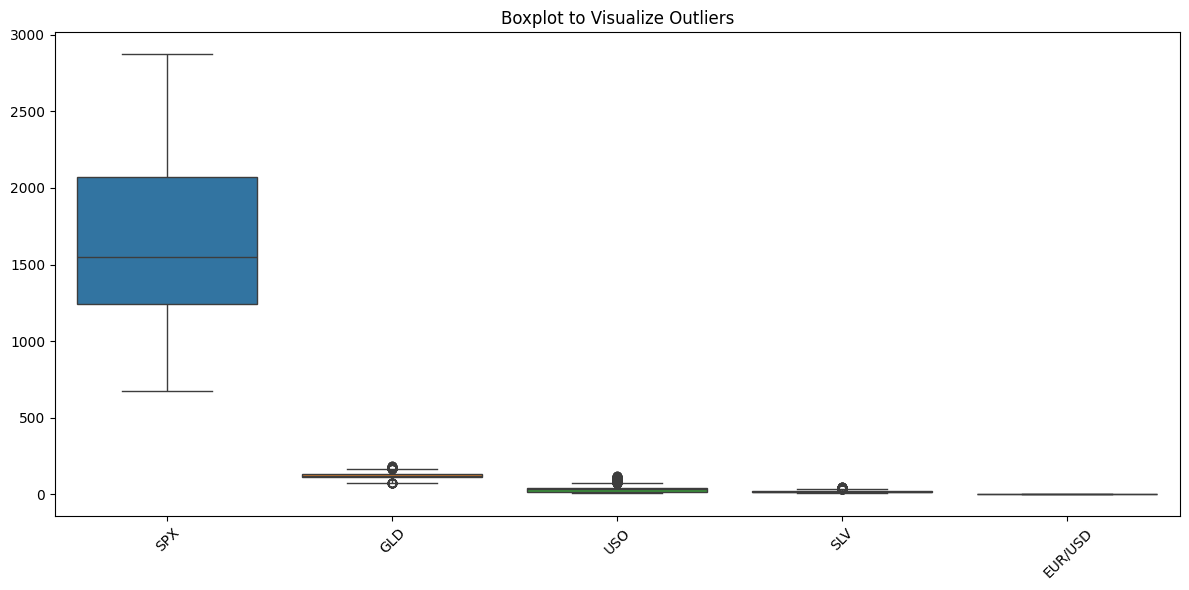

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Load data




# Step 2: Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Step 3: Compute Z-scores
z_scores = numeric_df.apply(zscore)

# Step 4: Count outliers per column
outliers = (abs(z_scores) > 3).sum()
print("Outlier counts per feature:\n", outliers)

# Step 5: Basic statistical summary
print("\nBasic Statistics:\n", numeric_df.describe())

# Step 6: Combine and display
summary_df = pd.concat([outliers.rename("Outlier_Count"), numeric_df.describe().T], axis=1)
print("\nCombined Summary:\n", summary_df)

# Step 7: Boxplot for visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=numeric_df)
plt.title("Boxplot to Visualize Outliers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [24]:
z_uso = zscore(df['USO'])
z_slv = zscore(df['SLV'])

# Keep rows where both z-score are within threshold
condition = (abs(z_uso) <= 3) & (abs(z_slv) <=3)
df_no_outliers = df[condition]

# Show results
print(f"Original rows: {len(df)}")
print(f"Rows after removing USO and SLV outliers: {len(df_no_outliers)}")
print(f"Removed rows: {len(df) - len(df_no_outliers)}")

Original rows: 2290
Rows after removing USO and SLV outliers: 2217
Removed rows: 73


SPX         0
GLD         0
USO        56
SLV         3
EUR/USD     0
dtype: int64

In [28]:
# Compute correlation matrix 
correlation_matrix = df.corr(numeric_only=True)

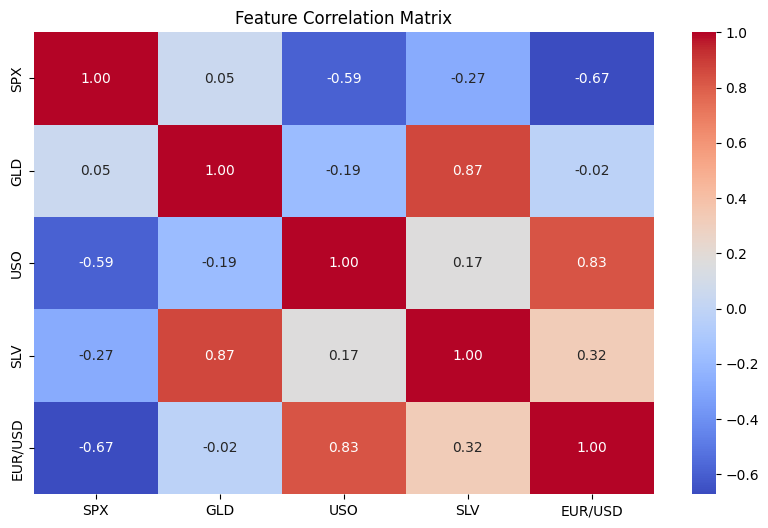

In [29]:
# visualize with a heatmap
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

In [37]:
# Assume df_model is your cleaned DataFrame without 'Date'
correlation_matrix = df.corr()

# Correlation of all features with GLD
correlation_with_gld = correlation_matrix['GLD'].abs().sort_values(ascending=False)
print("Features most correlated with GLD:\n", correlation_with_gld)

# Choose top features excluding GLD itself
top_features = correlation_with_gld.drop('GLD')
selected_features = top_features[top_features > 0.5].index.tolist()

print("\nSelected features for modeling:", selected_features)

# Now prepare your data
X = df[['SLV','USO','SPX']]
y = df['GLD']


Features most correlated with GLD:
 GLD        1.000000
SLV        0.866632
USO        0.186360
SPX        0.049345
EUR/USD    0.024375
Name: GLD, dtype: float64

Selected features for modeling: ['SLV']


In [38]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_teain,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# For storing the result of each model then compare them z

In [63]:
results = []

# Train a linear Regression model


In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score ,mean_absolute_error

model = LinearRegression()
model.fit(X_train,y_teain)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['LinearRegression', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])

R2_score 0.8969155673669311
MAE 5.599759825271183


## Ridge

In [65]:
from sklearn.linear_model import Ridge 

model =Ridge(alpha=1.0)
model.fit(X_train,y_teain)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['Ridge', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])

R2_score 0.8969147142392672
MAE 5.599817597408102


# Lasso

In [66]:
from sklearn.linear_model import Lasso
model = Lasso(alpha=0.1)
model.fit(X_train,y_teain)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['Lasso', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])

R2_score 0.89686569455024
MAE 5.602765282987655


# ElasticNet

In [67]:
from sklearn.linear_model import ElasticNet
model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train,y_teain)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['ElasticNet', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])

R2_score 0.8968108670123408
MAE 5.60665098445871


# DecisionTreeRegressor


In [68]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(max_depth=5, random_state=42)

model.fit(X_train,y_teain)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['DecisionTreeRegressor', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])


R2_score 0.9410338764177388
MAE 3.766450754330497


# RandomForestRegressor

In [82]:
from sklearn.ensemble import RandomForestRegressor

RandomForestModel= RandomForestRegressor(n_estimators=100,max_depth=10,random_state=42)

RandomForestModel.fit(X_train,y_teain)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['RandomForetRegressor', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])

R2_score 0.9636823890943254
MAE 3.095233027391867


# ExtraTreesRegressor

In [70]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor(n_estimators=100,max_depth=10,random_state=42)

model.fit(X_train,y_teain)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['ExtraTreesRegressor', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])

R2_score 0.9799022221831656
MAE 2.0980946429282468


# GradientBoostingRegressor

In [71]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=100,learning_rate=0.1, max_depth=3,random_state=2)

model.fit(X_train,y_teain)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['GradientBoostingRegressor', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])

R2_score 0.970289990536823
MAE 2.620890533444092


# HistGradientBoostingRegressor

In [72]:
from sklearn.ensemble import HistGradientBoostingRegressor

model = HistGradientBoostingRegressor(max_iter=100,learning_rate=0.1,max_depth=7, random_state=42)

model.fit(X_train,y_teain)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['HistGradientBoostingregressor', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])

R2_score 0.9801301835958985
MAE 1.8888897619940823


# XGBoost

In [73]:
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=100,learning_rate=0.1,max_depth=3,random_stata=42)

model.fit(X_train,y_teain)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['XGBoost', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])


R2_score 0.9709743219671491
MAE 2.554490143263638


# LightGBM

In [50]:
! pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 8.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

model.fit(X_train,y_teain)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['LGBMRegressor', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 1832, number of used features: 3
[LightGBM] [Info] Start training from score 122.901138
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

# CatBoost

In [55]:
! pip install catboost


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
    --------------------------------------- 1.8/102.5 MB 11.2 MB/s eta 0:00:10
   - -------------------------------------- 3.9/102.5 MB 10.7 MB/s eta 0:00:10
   -- ------------------------------------- 5.8/102.5 MB 9.8 MB/s eta 0:00:10
   --- ------------------------------------ 7.9/102.5 MB 9.7 MB/s eta 0:00:10
   --- ------------------------------------ 10.0/102.5 MB 9.8 MB/s eta 0:00:10
   ---- ----------------------------------- 11.8/102.5 MB 9.6 MB/s eta 0:00:10
   ----- ---------------------------------- 13.6/102.5 MB 9.4 MB/s eta 0:00:10
   ------ --------------------------------- 15.5/102.5 MB 9.4 MB/s eta 0:00:10
   ------ --------------------------------- 17.6/102.5 MB 9.3 MB/s eta 0:00:10
   ------- -------------------------------- 19.4/102.5 MB 9.3 MB/s eta 0:00:09
   -------- ------------------------------- 21.5/102.5 MB 9.3 MB/s eta 0:00:09
   --------- ------------------------------ 23.6/102.5 MB 9.3

In [75]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=3, silent=True, random_state=42)

model.fit(X_train,y_teain)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['CatBoostRegressor', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])

R2_score 0.9636823890943254
MAE 3.095233027391867


# Voting Regressor

In [76]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

model1 = LinearRegression()
model2 = RandomForestRegressor(n_estimators=100, random_state=42)

voting = VotingRegressor(estimators=[('lr', model1), ('rf', model2)])
voting.fit(X_train,y_teain)

# Predict
y_pred = voting.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['Voting Regressor', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])

R2_score 0.9622701245876146
MAE 3.2852020227950836


# StackingRegressor

In [77]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

base_models = [
    ('ridge', Ridge()),
    ('tree', DecisionTreeRegressor(max_depth=5))
]

stacking = StackingRegressor(estimators=base_models, final_estimator=LinearRegression())
stacking.fit(X_train,y_teain)

# Predict
y_pred = stacking.predict(X_test)

# Evaluate
print("R2_score",r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))
results.append(['StackingRegressor', r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)])

R2_score 0.9486933106727976
MAE 3.5818421038919808


# create data frame with all output

In [78]:
import pandas as pd
results_df =pd.DataFrame(results,columns=['Model','R2_score','MAE'])

results_df.sort_values(by='R2_score',ascending=False,inplace=True)
print(results_df)

                            Model  R2_score       MAE
5            RandomForetRegressor  0.984296  1.629700
8   HistGradientBoostingregressor  0.980130  1.888890
6             ExtraTreesRegressor  0.979902  2.098095
9                         XGBoost  0.970974  2.554490
7       GradientBoostingRegressor  0.970290  2.620891
10                  LGBMRegressor  0.968958  2.688104
11              CatBoostRegressor  0.963682  3.095233
12               Voting Regressor  0.962270  3.285202
13              StackingRegressor  0.948693  3.581842
4           DecisionTreeRegressor  0.941034  3.766451
0                LinearRegression  0.896916  5.599760
1                           Ridge  0.896915  5.599818
2                           Lasso  0.896866  5.602765
3                      ElasticNet  0.896811  5.606651


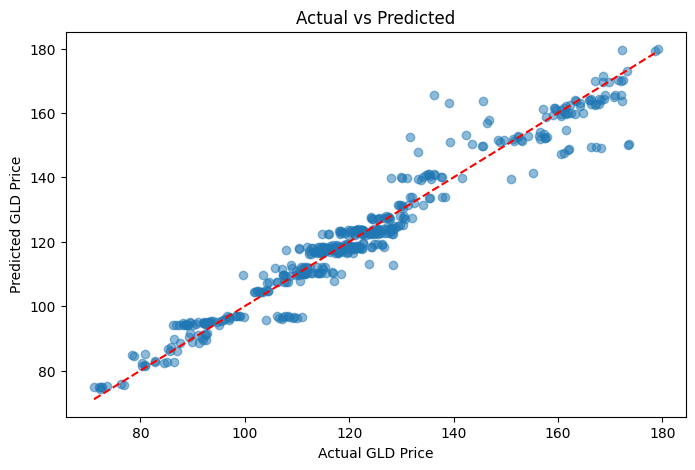

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual GLD Price")
plt.ylabel("Predicted GLD Price")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45° line
plt.show()


In [83]:
import joblib
joblib.dump(RandomForestModel, "gld_price_model.pkl")


['gld_price_model.pkl']

In [85]:
def predict_gld_price(slv, uso, spx):
    input_data = np.array([[slv, uso, spx]])
    return model.predict(input_data)[0]


In [86]:
predicted_price = predict_gld_price(slv=20.5, uso=30.1, spx=1500)
print(f"Predicted GLD Price: ₹{predicted_price:.2f}")


Predicted GLD Price: ₹126.60
